# Chapter 8: Continuous × Continuous Interactions — Tulips

## The Biology

Tulips need two things to bloom: **water** and **light**. But these don't simply add together — they *multiply*:

- Lots of water + low light (heavy shade) → barely any blooms. Light is the bottleneck.
- Lots of water + high light (low shade) → many blooms. Water *and* light amplify each other.

This is a **continuous × continuous interaction**: the slope of water on blooms depends on how much shade there is, and vice versa. Neither variable is categorical — both vary continuously.

## The Statistical Challenge

A non-interaction model assumes:
$$\mu_i = \alpha + \beta_W W_i + \beta_S S_i$$
This says the effect of water is the same regardless of shade. That's biologically wrong.

The interaction model allows the slope to vary:
$$\mu_i = \alpha + \beta_W W_i + \beta_S S_i + \beta_{WS} W_i S_i$$

Rearranging, the slope of water *conditional on shade* is:
$$\gamma_W = \beta_W + \beta_{WS} S_i$$

So $\beta_{WS}$ tells us: "for each unit increase in shade, how much does the water slope change?"

## Two Models

| Model | Formula | Assumption |
|-------|---------|------------|
| m_noint | α + βW·W + βS·S | Parallel lines — water effect same at all shade levels |
| **m_int** | **α + βW·W + βS·S + βWS·W·S** | **Slopes differ — water matters more when shade is low** |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import logsumexp
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))
from src.quap import quap

plt.style.use('default')
%matplotlib inline
np.random.seed(42)

print('✓ Imports loaded')

✓ Imports loaded


## Load and Prepare the Tulips Data

In [2]:
url = 'https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/tulips.csv'
tulips = pd.read_csv(url, sep=';')
print(tulips.head(10))
print(f'\nShape: {tulips.shape}')
print(f'Columns: {list(tulips.columns)}')
print(f'\nDescriptive stats:')
print(tulips.describe())

  bed  water  shade  blooms
0   a      1      1    0.00
1   a      1      2    0.00
2   a      1      3  111.04
3   a      2      1  183.47
4   a      2      2   59.16
5   a      2      3   76.75
6   a      3      1  224.97
7   a      3      2   83.77
8   a      3      3  134.95
9   b      1      1   80.10

Shape: (27, 4)
Columns: ['bed', 'water', 'shade', 'blooms']

Descriptive stats:
          water     shade      blooms
count  27.00000  27.00000   27.000000
mean    2.00000   2.00000  128.993704
std     0.83205   0.83205   92.683923
min     1.00000   1.00000    0.000000
25%     1.00000   1.00000   71.115000
50%     2.00000   2.00000  111.040000
75%     3.00000   3.00000  190.300000
max     3.00000   3.00000  361.660000


In [3]:
# Scale and center following the book (Section 8.3)
#   B: blooms scaled to [0, 1] by dividing by max
#   W: water centred (subtract mean) → mean 0
#   S: shade centred (subtract mean) → mean 0

df = tulips.copy()
df['B'] = df['blooms'] / df['blooms'].max()   # scale blooms to [0,1]
df['W'] = df['water'] - df['water'].mean()     # centre water
df['S'] = df['shade'] - df['shade'].mean()     # centre shade

B = df['B'].values
W = df['W'].values
S = df['S'].values

print('After scaling/centering:')
print(f'  B (blooms): range [{B.min():.3f}, {B.max():.3f}],  mean = {B.mean():.3f}')
print(f'  W (water):  range [{W.min():.1f}, {W.max():.1f}],     mean = {W.mean():.3f}')
print(f'  S (shade):  range [{S.min():.1f}, {S.max():.1f}],     mean = {S.mean():.3f}')
print()
print('Centering W and S means:')
print('  α = expected blooms at average water AND average shade  (interpretable!)')
print('  βW = slope of water at MEAN shade')
print('  βS = slope of shade at MEAN water')
print('  βWS = how much βW changes per unit of shade')

After scaling/centering:
  B (blooms): range [0.000, 1.000],  mean = 0.357
  W (water):  range [-1.0, 1.0],     mean = 0.000
  S (shade):  range [-1.0, 1.0],     mean = 0.000

Centering W and S means:
  α = expected blooms at average water AND average shade  (interpretable!)
  βW = slope of water at MEAN shade
  βS = slope of shade at MEAN water
  βWS = how much βW changes per unit of shade


## Explore the Raw Data

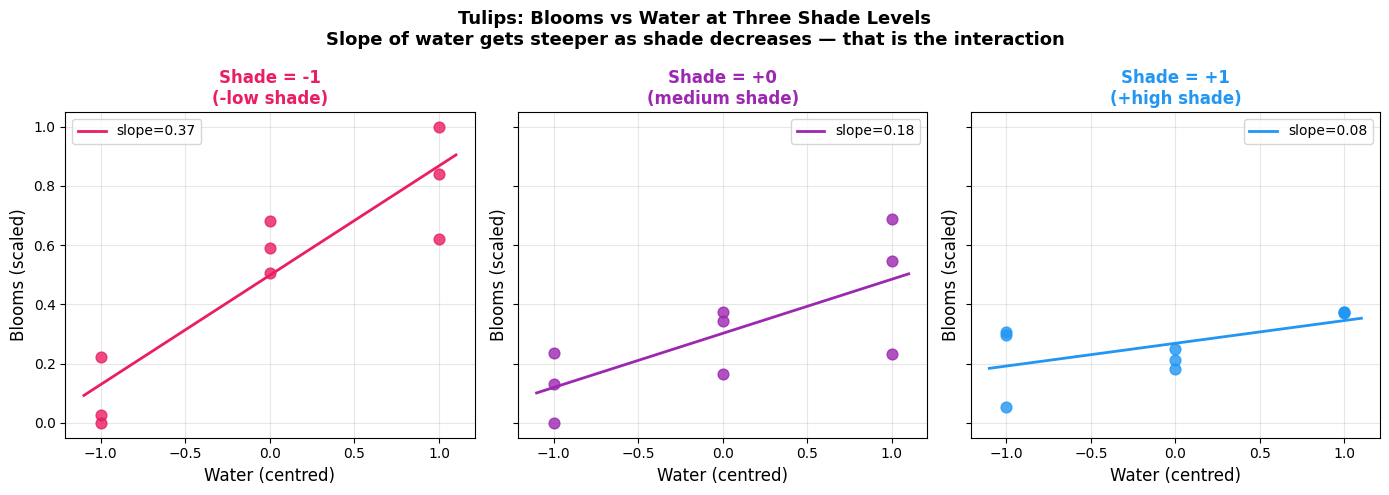

Observation: at low shade (-1), water has a strong positive effect.
At high shade (+1), water barely helps — light is the limiting factor.


In [4]:
# Quick look: blooms vs water, coloured by shade level
shade_vals  = sorted(df['S'].unique())
shade_labels = {s: f'shade = {s:+.0f}' for s in shade_vals}
colors = ['#E91E63', '#9C27B0', '#2196F3']   # pink=low shade, blue=high shade

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, (s_val, color) in zip(axes, zip(shade_vals, colors)):
    mask = df['S'] == s_val
    ax.scatter(df.loc[mask, 'W'], df.loc[mask, 'B'],
               s=60, color=color, alpha=0.8, zorder=3)
    # OLS trend
    x_sub = df.loc[mask, 'W'].values
    y_sub = df.loc[mask, 'B'].values
    if len(x_sub) > 1:
        m, b = np.polyfit(x_sub, y_sub, 1)
        xr = np.linspace(x_sub.min() - 0.1, x_sub.max() + 0.1, 50)
        ax.plot(xr, m*xr + b, color=color, lw=2, label=f'slope={m:.2f}')
    ax.set_xlabel('Water (centred)', fontsize=12)
    ax.set_ylabel('Blooms (scaled)', fontsize=12)
    ax.set_title(f'Shade = {s_val:+.0f}\n({"-low" if s_val < 0 else "+high" if s_val > 0 else "medium"} shade)',
                 fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Tulips: Blooms vs Water at Three Shade Levels\n'
             'Slope of water gets steeper as shade decreases — that is the interaction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: at low shade (-1), water has a strong positive effect.')
print('At high shade (+1), water barely helps — light is the limiting factor.')

## Prior Predictive Simulation

Before fitting, simulate regression lines from the prior to check they produce plausible blooms.

Blooms are scaled to [0, 1], so lines should mostly stay in that range.

**Priors** (following the book):
- `α ~ Normal(0.5, 0.25)` — blooms centred in [0,1]; ±2σ covers [0,1] almost exactly
- `βW ~ Normal(0, 0.25)` — positive expected; a slope of 0.25 on the centred scale is already quite large
- `βS ~ Normal(0, 0.25)` — negative expected; same reasoning
- `βWS ~ Normal(0, 0.25)` — interaction; same scale

We check both models: with and without the interaction term.

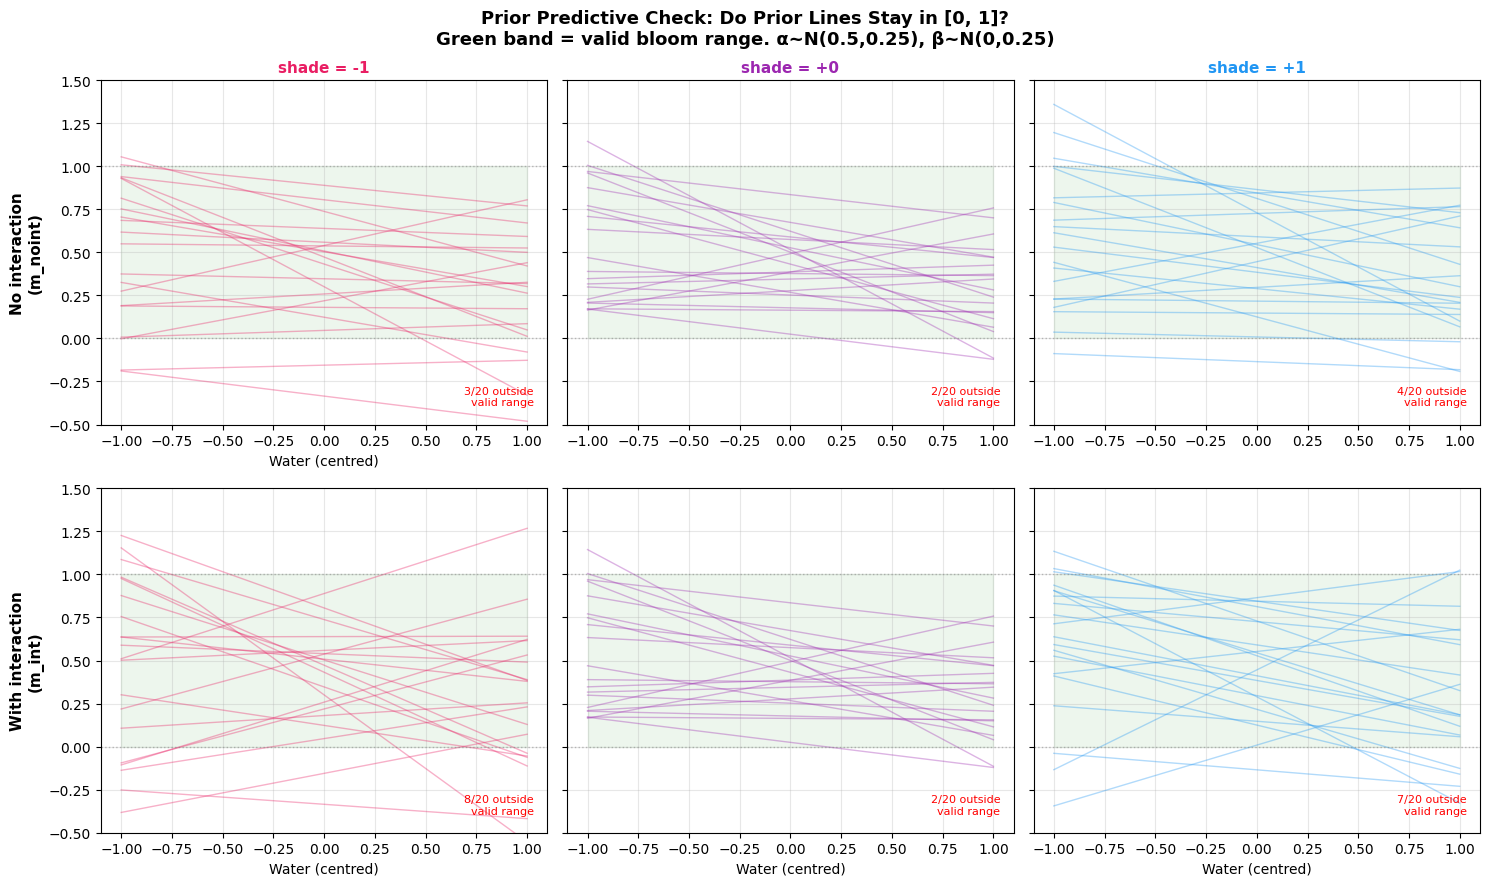

In [5]:
rng = np.random.default_rng(7)
n_prior = 20
w_seq = np.linspace(W.min(), W.max(), 100)

# Draw prior samples
a_prior   = rng.normal(0.5, 0.25, n_prior)
bW_prior  = rng.normal(0,   0.25, n_prior)
bS_prior  = rng.normal(0,   0.25, n_prior)
bWS_prior = rng.normal(0,   0.25, n_prior)

shade_vals_plot = [-1, 0, 1]
shade_colors    = ['#E91E63', '#9C27B0', '#2196F3']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)

for col, (s_val, color) in enumerate(zip(shade_vals_plot, shade_colors)):
    # --- Row 0: no interaction ---
    ax = axes[0, col]
    n_bad = 0
    for a, bw, bs in zip(a_prior, bW_prior, bS_prior):
        mu = a + bw * w_seq + bs * s_val
        ax.plot(w_seq, mu, color=color, alpha=0.35, lw=1)
        if mu.max() > 1.1 or mu.min() < -0.1:
            n_bad += 1
    ax.axhline(0, color='gray', ls=':', lw=1, alpha=0.5)
    ax.axhline(1, color='gray', ls=':', lw=1, alpha=0.5)
    ax.fill_between(w_seq, 0, 1, alpha=0.07, color='green')
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f'shade = {s_val:+d}', fontsize=11, color=color, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel('No interaction\n(m_noint)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Water (centred)', fontsize=10)
    ax.text(0.97, 0.05, f'{n_bad}/{n_prior} outside\nvalid range',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='red')

    # --- Row 1: with interaction ---
    ax = axes[1, col]
    n_bad = 0
    for a, bw, bs, bws in zip(a_prior, bW_prior, bS_prior, bWS_prior):
        mu = a + bw * w_seq + bs * s_val + bws * w_seq * s_val
        ax.plot(w_seq, mu, color=color, alpha=0.35, lw=1)
        if mu.max() > 1.1 or mu.min() < -0.1:
            n_bad += 1
    ax.axhline(0, color='gray', ls=':', lw=1, alpha=0.5)
    ax.axhline(1, color='gray', ls=':', lw=1, alpha=0.5)
    ax.fill_between(w_seq, 0, 1, alpha=0.07, color='green')
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('Water (centred)', fontsize=10)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel('With interaction\n(m_int)', fontsize=11, fontweight='bold')
    ax.text(0.97, 0.05, f'{n_bad}/{n_prior} outside\nvalid range',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='red')

plt.suptitle('Prior Predictive Check: Do Prior Lines Stay in [0, 1]?\n'
             'Green band = valid bloom range. α~N(0.5,0.25), β~N(0,0.25)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fit Model 1: No Interaction

$$\mu_i = \alpha + \beta_W W_i + \beta_S S_i$$

This model assumes the water-blooms slope is the same regardless of shade level — **parallel regression lines** across shade values.

In [6]:
def fit_noint(B, W, S):
    """No interaction: mu = alpha + bW*W + bS*S."""
    def nlp(params):
        alpha, bW, bS, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + bW * W + bS * S
        ll = np.sum(stats.norm.logpdf(B, mu, sigma))
        lp = (stats.norm.logpdf(alpha, 0.5, 0.25) +
              stats.norm.logpdf(bW,    0,   0.25) +
              stats.norm.logpdf(bS,    0,   0.25) +
              stats.expon.logpdf(sigma, scale=1))
        return -(ll + lp + log_sigma)

    m = quap(nlp, [0.5, 0.1, -0.1, np.log(0.1)],
             ['alpha', 'bW', 'bS', 'log_sigma'])
    m.transform_param('log_sigma', 'sigma', np.exp)
    return m


m_noint = fit_noint(B, W, S)
m_noint.summary()

✓ Registered transformation: log_sigma -> sigma
QUAP POSTERIOR APPROXIMATION
Converged: True
Time: 0.0248 seconds
Log posterior at MAP: 10.22

         mean    std  89%_lower  89%_upper
alpha  0.3588 0.0307     0.3095     0.4069
bW     0.2048 0.0377     0.1451     0.2654
bS    -0.1120 0.0373    -0.1714    -0.0522
sigma  0.1628 0.0227     0.1291     0.2007


,mean,std,89%_lower,89%_upper
alpha,0.358777,0.030731,0.309521,0.406898
bW,0.204794,0.037675,0.145121,0.265375
bS,-0.111981,0.037305,-0.171380,-0.052159
sigma,0.162842,0.022713,0.129129,0.200744


## Fit Model 2: With Interaction

$$\mu_i = \alpha + \beta_W W_i + \beta_S S_i + \beta_{WS} W_i S_i$$

The extra term $\beta_{WS} W_i S_i$ lets the water slope change with shade:
$$\gamma_W(S) = \beta_W + \beta_{WS} \cdot S$$

We expect $\beta_{WS} < 0$: as shade increases (more shade = less light), the water slope should decrease.

In [7]:
def fit_int(B, W, S):
    """Full interaction: mu = alpha + bW*W + bS*S + bWS*W*S."""
    def nlp(params):
        alpha, bW, bS, bWS, log_sigma = params
        sigma = np.exp(log_sigma)
        mu = alpha + bW * W + bS * S + bWS * W * S
        ll = np.sum(stats.norm.logpdf(B, mu, sigma))
        lp = (stats.norm.logpdf(alpha, 0.5, 0.25) +
              stats.norm.logpdf(bW,    0,   0.25) +
              stats.norm.logpdf(bS,    0,   0.25) +
              stats.norm.logpdf(bWS,   0,   0.25) +
              stats.expon.logpdf(sigma, scale=1))
        return -(ll + lp + log_sigma)

    m = quap(nlp, [0.5, 0.1, -0.1, -0.05, np.log(0.1)],
             ['alpha', 'bW', 'bS', 'bWS', 'log_sigma'])
    m.transform_param('log_sigma', 'sigma', np.exp)
    return m


m_int = fit_int(B, W, S)
m_int.summary()

coefs = m_int.coef()
print()
print(f'βWS = {coefs["bWS"]:+.3f}')
print()
print('Conditional slopes of water at each shade level:')
for s_val in [-1, 0, 1]:
    gamma_W = coefs['bW'] + coefs['bWS'] * s_val
    print(f'  shade = {s_val:+d}:  γW = βW + βWS·S = {coefs["bW"]:.3f} + ({coefs["bWS"]:.3f})·({s_val}) = {gamma_W:+.3f}')

✓ Registered transformation: log_sigma -> sigma
QUAP POSTERIOR APPROXIMATION
Converged: True
Time: 0.0409 seconds
Log posterior at MAP: 16.71

         mean    std  89%_lower  89%_upper
alpha  0.3581 0.0241     0.3190     0.3959
bW     0.2066 0.0296     0.1589     0.2536
bS    -0.1131 0.0299    -0.1607    -0.0653
bWS   -0.1436 0.0362    -0.2022    -0.0861
sigma  0.1285 0.0181     0.1017     0.1591

βWS = -0.144

Conditional slopes of water at each shade level:
  shade = -1:  γW = βW + βWS·S = 0.207 + (-0.144)·(-1) = +0.350
  shade = +0:  γW = βW + βWS·S = 0.207 + (-0.144)·(0) = +0.207
  shade = +1:  γW = βW + βWS·S = 0.207 + (-0.144)·(1) = +0.063


## WAIC Model Comparison

In [8]:
def compute_waic(model, B, W, S, has_interaction=False, n_samples=10_000):
    """Compute WAIC from quap posterior samples."""
    samples = model.sample(n=n_samples, seed=42)
    alpha_s = samples['alpha'].values
    bW_s    = samples['bW'].values
    bS_s    = samples['bS'].values
    sigma_s = samples['sigma'].values

    if has_interaction:
        bWS_s = samples['bWS'].values
        mu_mat = (alpha_s[:, None]
                  + bW_s[:, None]  * W[None, :]
                  + bS_s[:, None]  * S[None, :]
                  + bWS_s[:, None] * W[None, :] * S[None, :])  # (S, N)
    else:
        mu_mat = (alpha_s[:, None]
                  + bW_s[:, None] * W[None, :]
                  + bS_s[:, None] * S[None, :])                 # (S, N)

    log_lik  = stats.norm.logpdf(B[None, :], mu_mat, sigma_s[:, None])  # (S, N)
    lppd_i   = logsumexp(log_lik, axis=0) - np.log(n_samples)
    p_waic_i = log_lik.var(axis=0)
    waic_i   = -2 * (lppd_i - p_waic_i)
    n_obs    = len(B)
    return dict(waic=waic_i.sum(), lppd=lppd_i.sum(),
                p_waic=p_waic_i.sum(), se=np.sqrt(n_obs * waic_i.var()))


w_noint = compute_waic(m_noint, B, W, S, has_interaction=False)
w_int   = compute_waic(m_int,   B, W, S, has_interaction=True)

best = min(w_noint['waic'], w_int['waic'])
rows = []
for name, w in [('m_noint: no interaction', w_noint), ('m_int: with interaction', w_int)]:
    rows.append(dict(Model=name, WAIC=round(w['waic'],1), lppd=round(w['lppd'],2),
                     p_WAIC=round(w['p_waic'],2), SE=round(w['se'],1),
                     dWAIC=round(w['waic']-best, 1)))

df_cmp = pd.DataFrame(rows)
print('WAIC model comparison:')
print('=' * 70)
print(df_cmp.to_string(index=False))
print('=' * 70)
print()
dw = w_noint['waic'] - w_int['waic']
se_diff = np.sqrt(w_noint['se']**2 + w_int['se']**2)
print(f'dWAIC = {dw:.1f}  (SE of difference ≈ {se_diff:.1f})')
if abs(dw) > 2 * se_diff:
    print('✓ Interaction model reliably better — the interaction is real')
else:
    print('⚠  Difference is within 2 SE — modest evidence for interaction')

WAIC model comparison:
                  Model  WAIC  lppd  p_WAIC  SE  dWAIC
m_noint: no interaction -12.9 11.32    4.88 8.4   10.5
m_int: with interaction -23.4 17.52    5.84 9.5    0.0

dWAIC = 10.5  (SE of difference ≈ 12.7)
⚠  Difference is within 2 SE — modest evidence for interaction


## The Triptych Plot

McElreath's key visualisation for continuous interactions: plot the outcome vs one predictor, **separately for three values of the other predictor** (low / medium / high).

- **Top row**: m_noint — identical (parallel) slopes in each panel
- **Bottom row**: m_int — slopes change across panels

The bottom row shows the biology: water's effect is steep when shade is low (light available), and flat when shade is high (light limited).

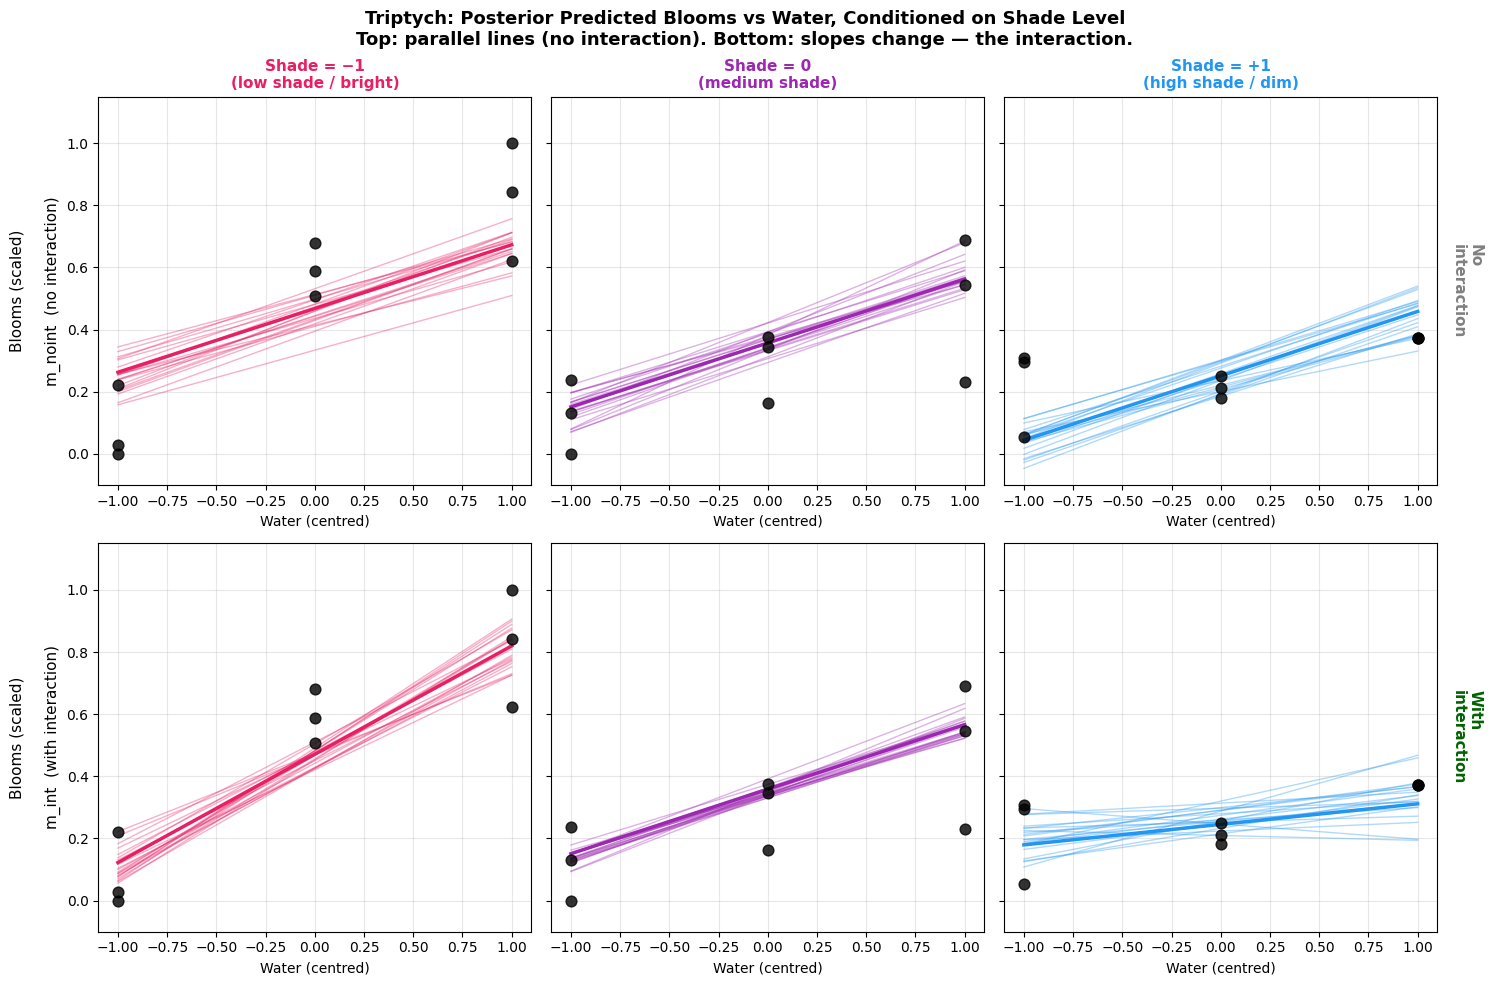

Conditional water slopes from m_int:
  shade = -1:  γW = +0.350  (steep)
  shade = +0:  γW = +0.207  (steep)
  shade = +1:  γW = +0.063  (shallow)


In [9]:
w_seq   = np.linspace(W.min(), W.max(), 50)
s_levels = {'Shade = −1\n(low shade / bright)': -1,
             'Shade = 0\n(medium shade)':         0,
             'Shade = +1\n(high shade / dim)':    1}
panel_colors = ['#E91E63', '#9C27B0', '#2196F3']
n_post = 20   # posterior lines per panel

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

for col, ((shade_label, s_val), color) in enumerate(
        zip(s_levels.items(), panel_colors)):

    # ── real data points at this shade level ─────────────────────────────────
    mask = np.isclose(S, s_val)

    # ── Row 0: no-interaction model ───────────────────────────────────────────
    ax = axes[0, col]
    samp = m_noint.sample(n=500, seed=col)
    for i in range(n_post):
        mu = (samp['alpha'].iloc[i]
              + samp['bW'].iloc[i] * w_seq
              + samp['bS'].iloc[i] * s_val)
        ax.plot(w_seq, mu, color=color, alpha=0.35, lw=1)

    # posterior mean line
    mu_mat = (samp['alpha'].values[:, None]
              + samp['bW'].values[:, None] * w_seq[None, :]
              + samp['bS'].values[:, None] * s_val)
    ax.plot(w_seq, mu_mat.mean(0), color=color, lw=2.5, label='posterior mean')
    ax.scatter(W[mask], B[mask], s=60, color='black', zorder=5, alpha=0.8)
    ax.set_ylim(-0.1, 1.15)
    ax.set_title(shade_label, fontsize=11, color=color, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel('Blooms (scaled)\n\nm_noint  (no interaction)', fontsize=11)
    ax.set_xlabel('Water (centred)', fontsize=10)

    # ── Row 1: interaction model ──────────────────────────────────────────────
    ax = axes[1, col]
    samp = m_int.sample(n=500, seed=col)
    for i in range(n_post):
        mu = (samp['alpha'].iloc[i]
              + samp['bW'].iloc[i]  * w_seq
              + samp['bS'].iloc[i]  * s_val
              + samp['bWS'].iloc[i] * w_seq * s_val)
        ax.plot(w_seq, mu, color=color, alpha=0.35, lw=1)

    mu_mat = (samp['alpha'].values[:, None]
              + samp['bW'].values[:, None]  * w_seq[None, :]
              + samp['bS'].values[:, None]  * s_val
              + samp['bWS'].values[:, None] * w_seq[None, :] * s_val)
    ax.plot(w_seq, mu_mat.mean(0), color=color, lw=2.5, label='posterior mean')
    ax.scatter(W[mask], B[mask], s=60, color='black', zorder=5, alpha=0.8)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, alpha=0.3)
    if col == 0:
        ax.set_ylabel('Blooms (scaled)\n\nm_int  (with interaction)', fontsize=11)
    ax.set_xlabel('Water (centred)', fontsize=10)

# Row labels on the right
axes[0, 2].text(1.03, 0.5, 'No\ninteraction', transform=axes[0, 2].transAxes,
                va='center', ha='left', fontsize=11, rotation=-90,
                color='gray', fontweight='bold')
axes[1, 2].text(1.03, 0.5, 'With\ninteraction', transform=axes[1, 2].transAxes,
                va='center', ha='left', fontsize=11, rotation=-90,
                color='darkgreen', fontweight='bold')

plt.suptitle(
    'Triptych: Posterior Predicted Blooms vs Water, Conditioned on Shade Level\n'
    'Top: parallel lines (no interaction). Bottom: slopes change — the interaction.',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Print conditional slopes from m_int
coefs = m_int.coef()
print('Conditional water slopes from m_int:')
for s_val in [-1, 0, 1]:
    g = coefs['bW'] + coefs['bWS'] * s_val
    print(f'  shade = {s_val:+d}:  γW = {g:+.3f}  '
          f'({"steep" if g > 0.15 else "shallow" if g > 0 else "flat/negative"})')

## Posterior Distributions of Parameters

The interaction coefficient βWS is the key parameter — its posterior distribution tells us how confidently the model has learned that water's effect depends on shade.

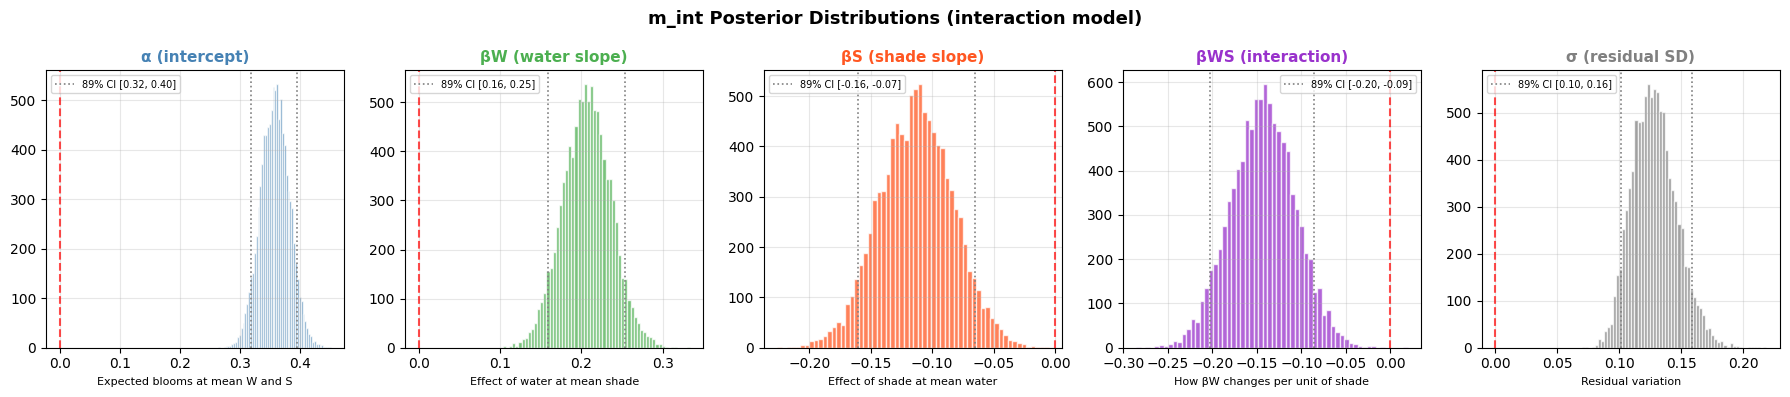

βWS posterior:
  Mean  = -0.144
  89% CI = [-0.202, -0.086]
  P(βWS < 0) = 100.0%  (expected: shade reduces water effectiveness)
  ✓ Entire 89% CI is negative — strong evidence for the interaction


In [10]:
samples_int = m_int.sample(n=10_000, seed=42)

param_info = [
    ('alpha', 'α (intercept)',        'steelblue',   'Expected blooms at mean W and S'),
    ('bW',    'βW (water slope)',      '#4CAF50',     'Effect of water at mean shade'),
    ('bS',    'βS (shade slope)',      '#FF5722',     'Effect of shade at mean water'),
    ('bWS',   'βWS (interaction)',     'darkorchid',  'How βW changes per unit of shade'),
    ('sigma', 'σ (residual SD)',       'gray',        'Residual variation'),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (pname, plabel, color, desc) in zip(axes, param_info):
    vals = samples_int[pname].values
    ax.hist(vals, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='red', lw=1.5, ls='--', alpha=0.7)
    lo, hi = np.percentile(vals, [5.5, 94.5])
    ax.axvline(lo, color='gray', lw=1.2, ls=':')
    ax.axvline(hi, color='gray', lw=1.2, ls=':', label=f'89% CI [{lo:.2f}, {hi:.2f}]')
    ax.set_title(plabel, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel(desc, fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('m_int Posterior Distributions (interaction model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary of interaction parameter
bWS_s = samples_int['bWS'].values
lo89, hi89 = np.percentile(bWS_s, [5.5, 94.5])
prob_neg = (bWS_s < 0).mean()
print(f'βWS posterior:')
print(f'  Mean  = {bWS_s.mean():+.3f}')
print(f'  89% CI = [{lo89:+.3f}, {hi89:+.3f}]')
print(f'  P(βWS < 0) = {prob_neg:.1%}  (expected: shade reduces water effectiveness)')
if hi89 < 0:
    print('  ✓ Entire 89% CI is negative — strong evidence for the interaction')
elif lo89 < 0:
    print('  ⚠  CI crosses zero — interaction is uncertain')

## Symmetry: Read the Interaction from the Other Direction

Just as with the ruggedness example, the same model can be read two ways:

> **Reading A**: "Water's effect on blooms *depends on shade*."  
> **Reading B**: "Shade's effect on blooms *depends on water*."

Mathematically, both are the same model. The interaction term $\beta_{WS} W_i S_i$ is symmetric in W and S.

Reading B is also biologically sensible: at high water, shade matters a lot (plant has enough water, so light becomes limiting); at low water, shade barely matters (water is already limiting).

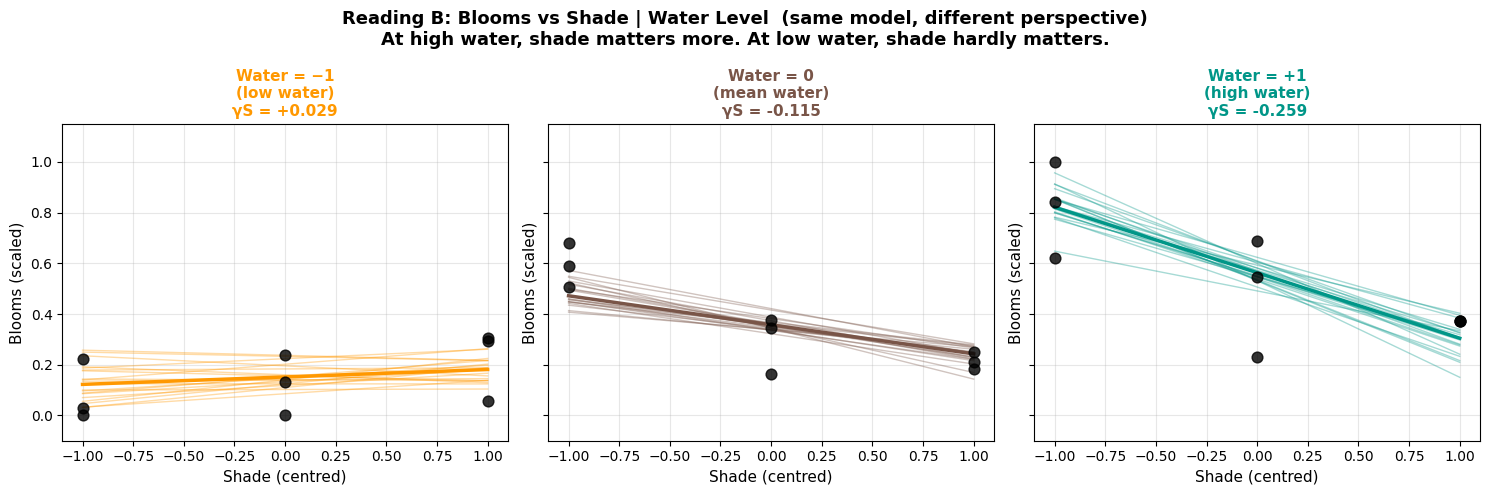

Conditional shade slopes (γS = βS + βWS·W):
  water = -1:  γS = +0.031
  water = +0:  γS = -0.113
  water = +1:  γS = -0.257


In [11]:
s_seq      = np.linspace(S.min(), S.max(), 50)
w_levels   = {'Water = −1\n(low water)':  -1,
              'Water = 0\n(mean water)':    0,
              'Water = +1\n(high water)':  +1}
w_colors   = ['#FF9800', '#795548', '#009688']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

samp = m_int.sample(n=500, seed=99)

for ax, ((water_label, w_val), color) in zip(axes,
        zip(w_levels.items(), w_colors)):
    mask = np.isclose(W, w_val)

    for i in range(n_post):
        mu = (samp['alpha'].iloc[i]
              + samp['bW'].iloc[i]  * w_val
              + samp['bS'].iloc[i]  * s_seq
              + samp['bWS'].iloc[i] * w_val * s_seq)
        ax.plot(s_seq, mu, color=color, alpha=0.35, lw=1)

    mu_mat = (samp['alpha'].values[:, None]
              + samp['bW'].values[:, None]  * w_val
              + samp['bS'].values[:, None]  * s_seq[None, :]
              + samp['bWS'].values[:, None] * w_val * s_seq[None, :])
    ax.plot(s_seq, mu_mat.mean(0), color=color, lw=2.5)
    ax.scatter(S[mask], B[mask], s=60, color='black', zorder=5, alpha=0.8)

    # Conditional slope of shade at this water level
    gamma_S = samp['bS'].mean() + samp['bWS'].mean() * w_val
    ax.set_xlabel('Shade (centred)', fontsize=11)
    ax.set_ylabel('Blooms (scaled)', fontsize=11)
    ax.set_title(f'{water_label}\nγS = {gamma_S:+.3f}', fontsize=11,
                 fontweight='bold', color=color)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Reading B: Blooms vs Shade | Water Level  (same model, different perspective)\n'
    'At high water, shade matters more. At low water, shade hardly matters.',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

coefs = m_int.coef()
print('Conditional shade slopes (γS = βS + βWS·W):')
for w_val in [-1, 0, 1]:
    g = coefs['bS'] + coefs['bWS'] * w_val
    print(f'  water = {w_val:+d}:  γS = {g:+.3f}')

## Key Insights

### 1. Centering unlocks interpretable parameters
By centering W and S around their means, every parameter has a clear meaning:
- α = expected blooms at average conditions
- βW = water slope at average shade
- βS = shade slope at average water  
- βWS = how much the water slope changes per unit of shade

Without centering, α would be the intercept at W=0 and S=0, which may be outside the data — uninterpretable.

### 2. The interaction term encodes a conditional slope
The model `mu = α + βW·W + βS·S + βWS·W·S` is equivalent to:
```
mu = α + (βW + βWS·S)·W + βS·S
       = α + γW(S)·W + βS·S
```
where γW(S) = βW + βWS·S is the water slope *conditional on shade*.

### 3. The triptych is the right visualisation
- Show outcome vs predictor X at 3 levels of moderator Z
- If the slopes change across panels → interaction is present
- If slopes are parallel → no interaction
- 20 posterior lines per panel shows uncertainty alongside the effect

### 4. Symmetry of interactions (again)
βWS·W·S = βWS·S·W — the model is symmetric. You can flip which variable is the "predictor" and which is the "moderator." The choice should come from your causal model and domain knowledge, not the regression output.

### 5. WAIC penalty is worth paying
The interaction model has one extra parameter (βWS) and a larger p_WAIC. If WAIC still prefers it, the interaction earns its complexity — the data contain a genuine slope-change signal.

---

*Section 8.3 — Statistical Rethinking (McElreath, 2nd ed.)*